In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

In [3]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
File_path = '/content/Walmart Data Analysis and Forcasting.csv'
preprocessing_data = pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

In [5]:
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

In [56]:
df["Date"] = pd.to_datetime(df["Date"],format ="%d""%m""%y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [7]:
preprocessing_data['Weekly_Sales_MinMax'] = min_max_scaler.fit_transform(preprocessing_data[['Weekly_Sales']])
preprocessing_data['Weekly_Sales_Standard'] = standard_scaler.fit_transform(preprocessing_data[['Weekly_Sales']])

In [8]:
preprocessing_data['Temperature_MinMax'] = min_max_scaler.fit_transform(preprocessing_data[['Temperature']])
preprocessing_data['Temperature_Standard'] = standard_scaler.fit_transform(preprocessing_data[['Temperature']])

In [11]:
preprocessing_data['Fuel_Price_MinMax'] = min_max_scaler.fit_transform(preprocessing_data[['Fuel_Price']])
preprocessing_data['Fuel_Price_Standard'] = standard_scaler.fit_transform(preprocessing_data[['Fuel_Price']])

In [12]:
preprocessing_data['CPI_MinMax'] = min_max_scaler.fit_transform(preprocessing_data[['CPI']])
preprocessing_data['CPI_Standard'] = standard_scaler.fit_transform(preprocessing_data[['CPI']])

In [13]:
preprocessing_data['Unemployment_MinMax'] = min_max_scaler.fit_transform(preprocessing_data[['Unemployment']])
preprocessing_data['Unemployment_Standard'] = standard_scaler.fit_transform(preprocessing_data[['Unemployment']])

In [16]:
preprocessing_data[['Store','Weekly_Sales_MinMax','Weekly_Sales_Standard','Temperature_MinMax','Temperatures_Standard','Fuel_Price_MinMax','Fuel_Price_Standard','CPI_MinMax','CPI_Standard','Unemployment_MinMax','Unemployment_Standard']]

,Store,Weekly_Sales_MinMax,Weekly_Sales_Standard,Temperature_MinMax,Temperatures_Standard,Fuel_Price_MinMax,Fuel_Price_Standard,CPI_MinMax,CPI_Standard,Unemployment_MinMax,Unemployment_Standard
0,1,0.050100,1.057420,0.434149,-0.995136,0.050100,-1.713800,0.840500,1.004175,0.405118,0.056964
1,1,0.038076,1.054348,0.396967,-1.201170,0.038076,-1.766089,0.841941,1.007880,0.405118,0.056964
2,1,0.021042,1.001206,0.410861,-1.124178,0.021042,-1.840166,0.842405,1.009074,0.405118,0.056964
3,1,0.044589,0.642828,0.476419,-0.760907,0.044589,-1.737766,0.842707,1.009849,0.405118,0.056964
4,1,0.076653,0.899914,0.475147,-0.767955,0.076653,-1.598328,0.843008,1.010624,0.405118,0.056964
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,0.764028,-0.591489,0.654990,0.228602,0.764028,1.390883,0.651876,0.519270,0.460514,0.365109
6431,45,0.758016,-0.555551,0.655088,0.229144,0.758016,1.364738,0.653427,0.523256,0.458884,0.356046
6432,45,0.765531,-0.553762,0.553131,-0.335825,0.765531,1.397419,0.654977,0.527241,0.458884,0.356046
6433,45,0.750000,-0.582715,0.572701,-0.227385,0.750000,1.329879,0.655013,0.527332,0.458884,0.356046


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
X= df.drop(columns=["Weekly_Sales"])
y= df["Weekly_Sales"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
model = LinearRegression()
# X_train already has 'Date' column removed
X_train_numeric = X_train
model.fit(X_train_numeric, y_train)

LinearRegression()

In [67]:
X_test_numeric = X_test
y_pred = model.predict(X_test_numeric)

In [68]:
r2 = r2_score(y_test, y_pred)

In [69]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1270
RMSE: 0.9464


Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment  
count  6435.000000  6435.000000  6435.000000   6435.000000  
mean     60.663782     3.358607   171.5783

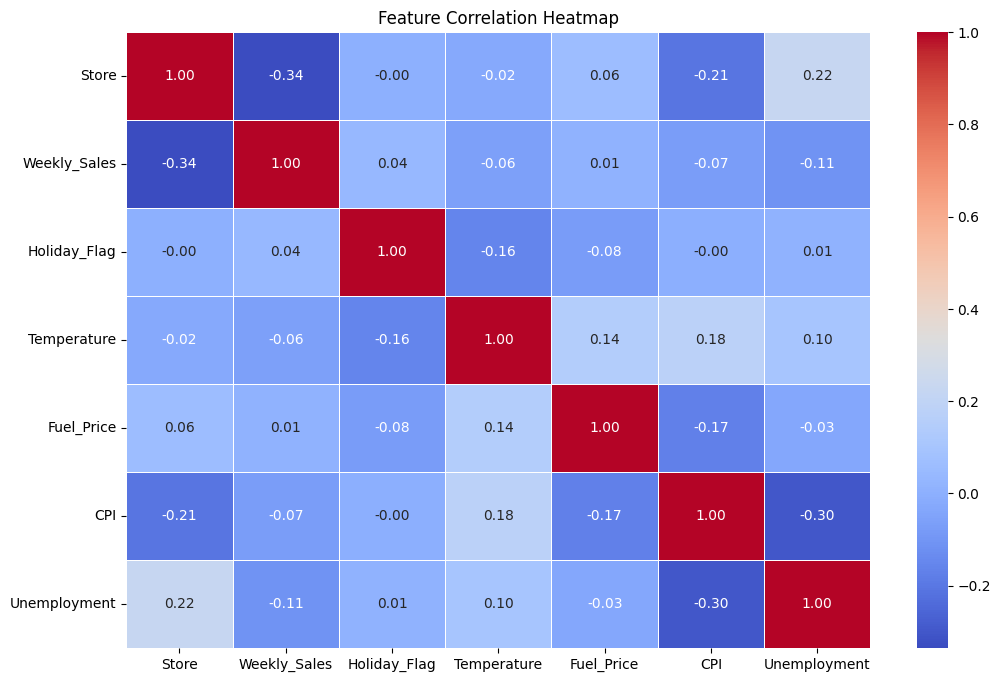

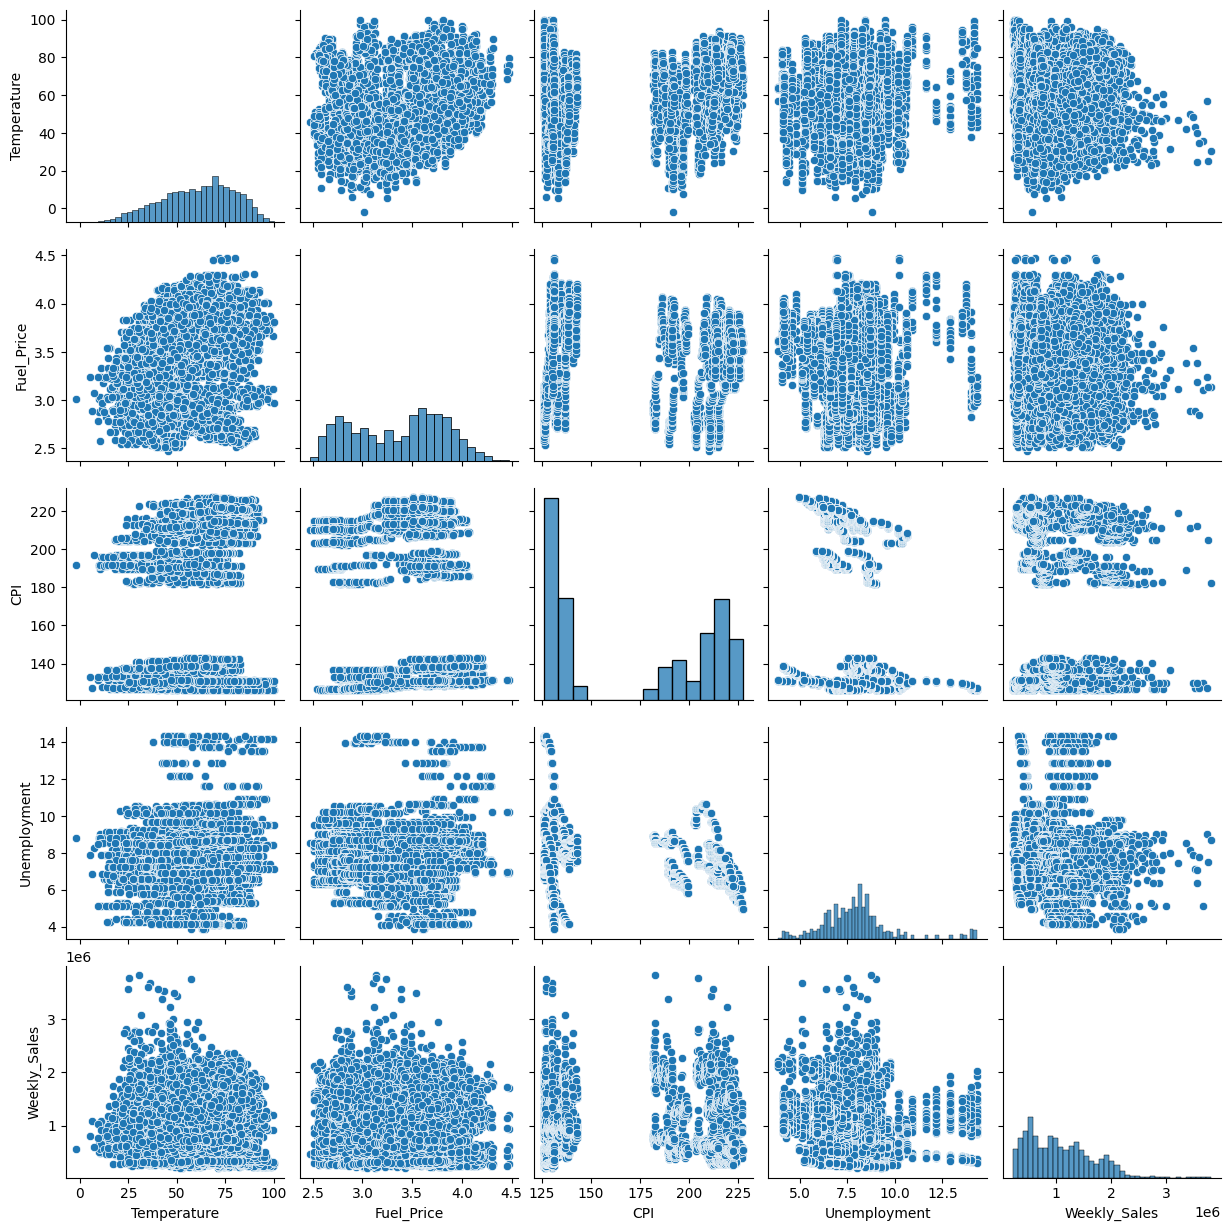

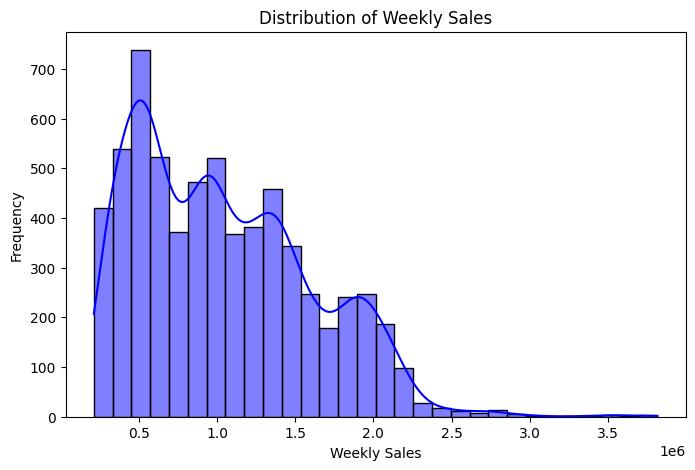

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Convert 'Date' column to datetime objects (optional for some analyses, but good practice)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
# Drop the 'Date' column before calculating correlation as it's not numeric
sns.heatmap(df.drop(columns=['Date']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment','Weekly_Sales']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

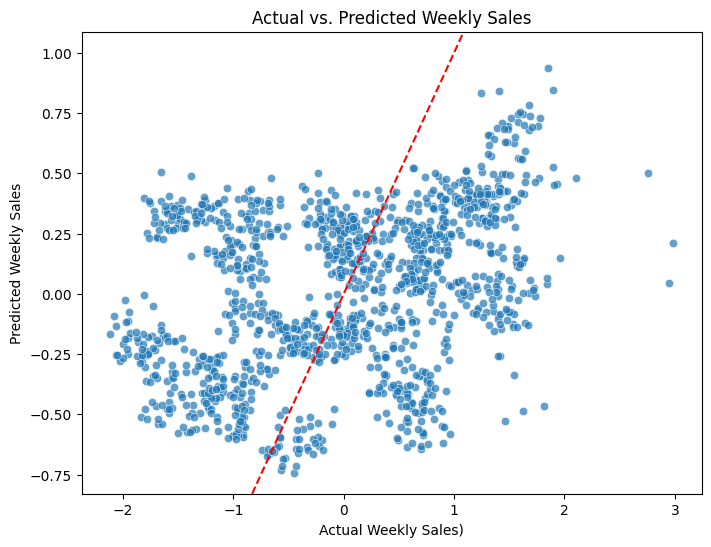

In [71]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha = 0.7)
plt.xlabel("Actual Weekly Sales)")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs. Predicted Weekly Sales")
plt.axline([0,0],[1,1],color = "red",linestyle="--")

In [72]:
from scipy.stats import skew


In [73]:
skewness = df.drop(columns=['Date']).skew()

In [74]:
num_cols = len(df.columns)
plt.figure(figsize=(15,num_cols*3))

<Figure size 1500x2400 with 0 Axes>

<Figure size 1500x2400 with 0 Axes>

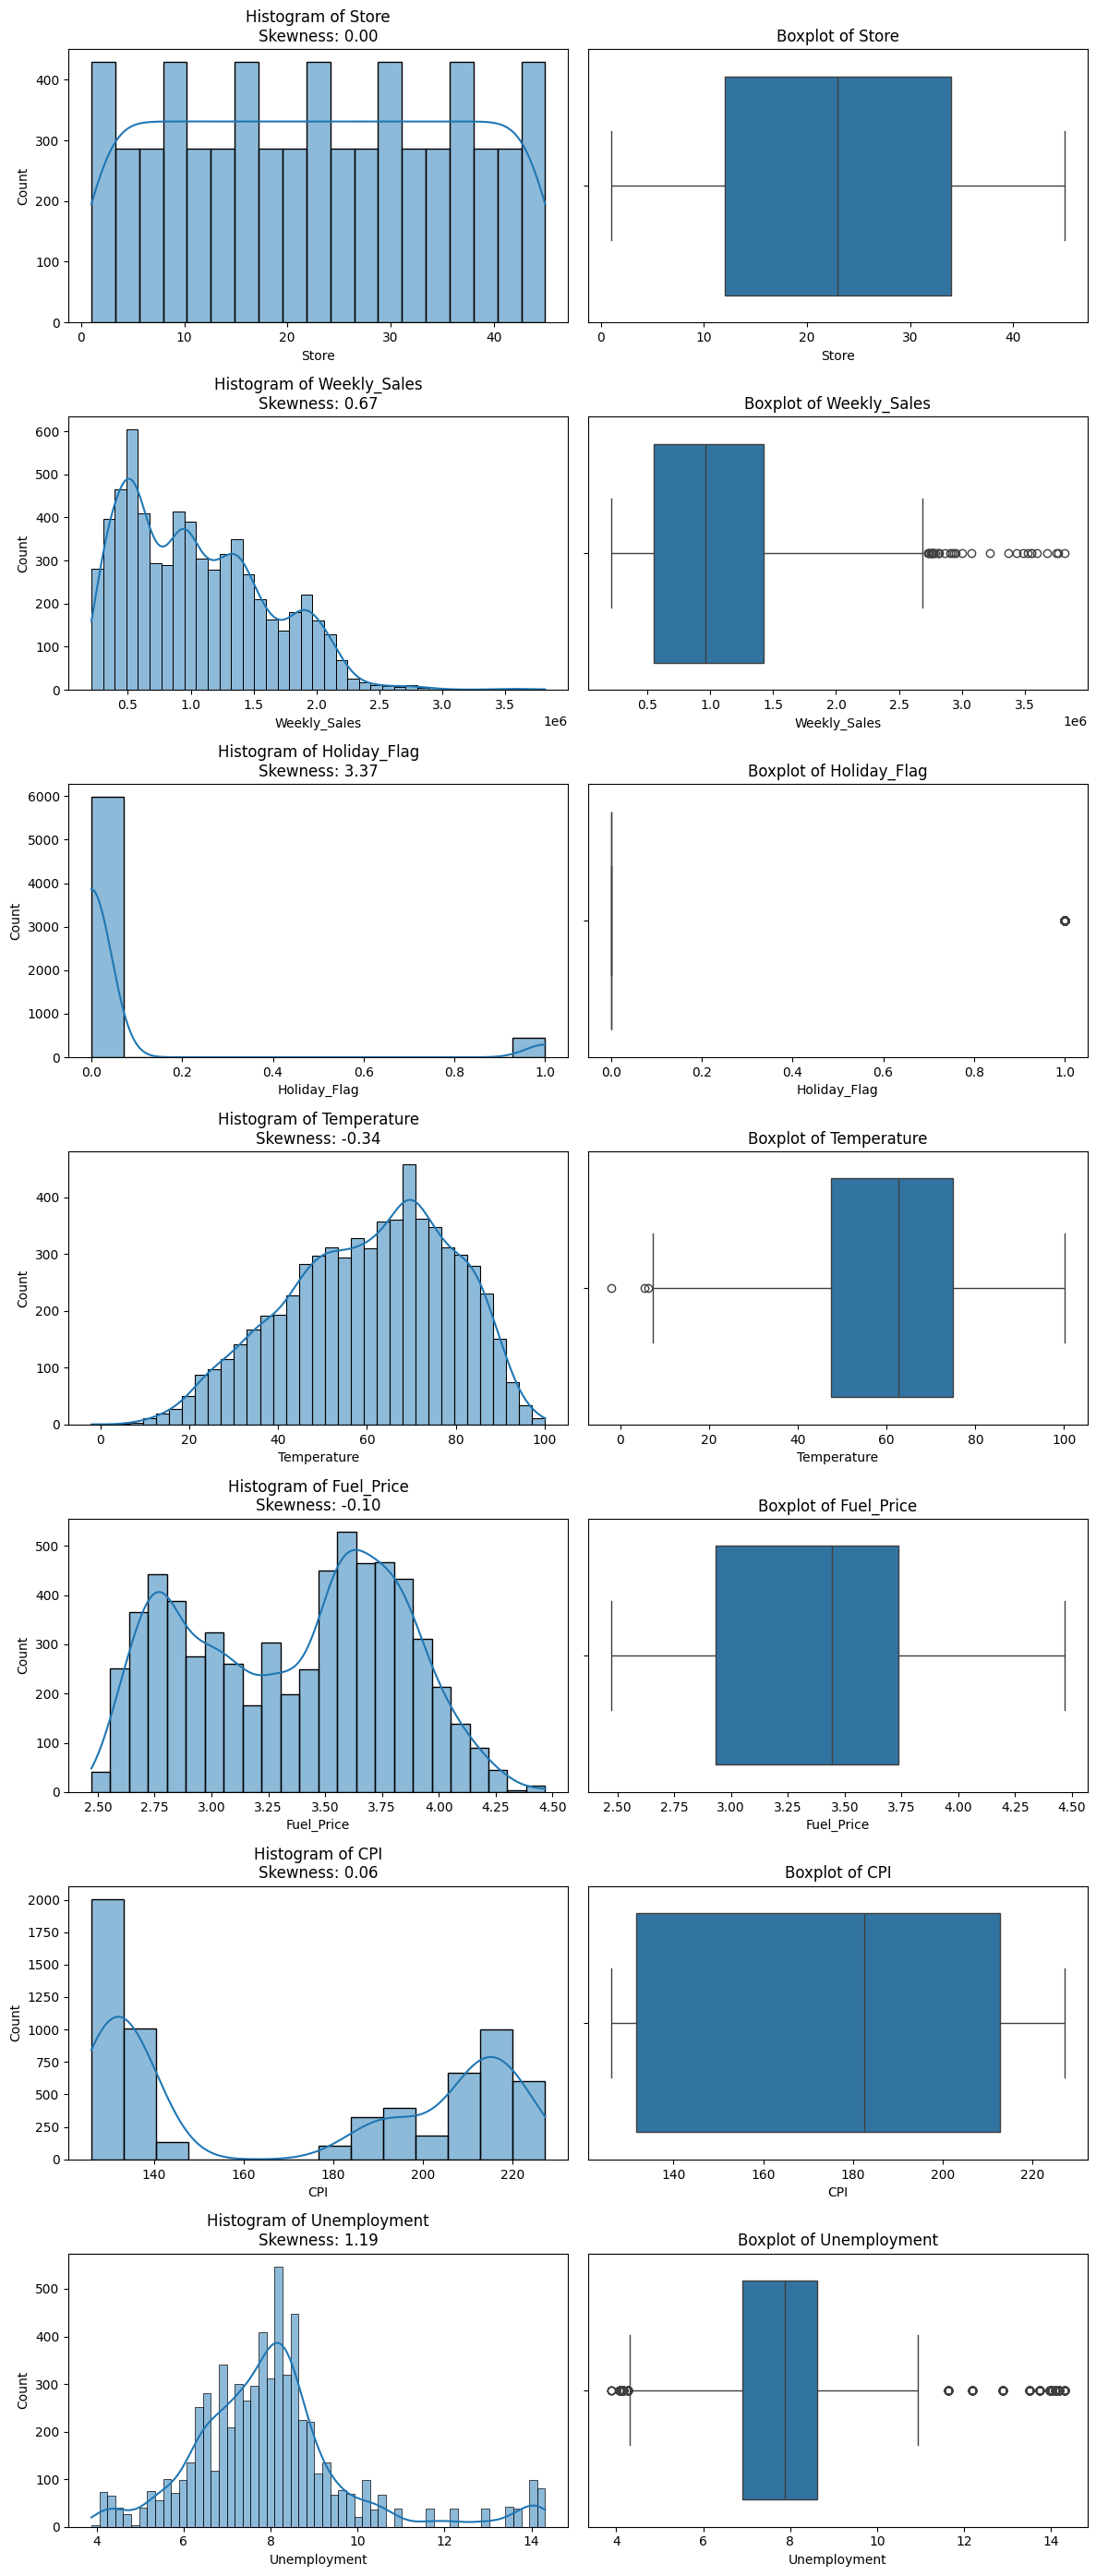

In [75]:
plt.figure(figsize=(12, 4 * len(skewness.index)))

for i, col in enumerate(skewness.index):
    # Histogram
    plt.subplot(len(skewness.index), 2, 2*i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

    # Boxplot
    plt.subplot(len(skewness.index), 2, 2*i + 2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [76]:
skewness = df.drop(columns=['Date']).skew()
print(skewness)

Store           0.000000
Weekly_Sales    0.668362
Holiday_Flag    3.373499
Temperature    -0.336768
Fuel_Price     -0.096158
CPI             0.063492
Unemployment    1.188144
dtype: float64


In [77]:
import numpy as np

In [78]:
skewed_cols = df.drop(columns=['Date']).skew().abs()
highly_skewed= skewed_cols[skewed_cols>1].index
negatively_skewed = skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [79]:
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

In [80]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df[negatively_skewed] = pt.fit_transform(df[negatively_skewed])

In [81]:
df.drop(columns=['Date']).skew()

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and Date
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1270
RMSE: 0.9464


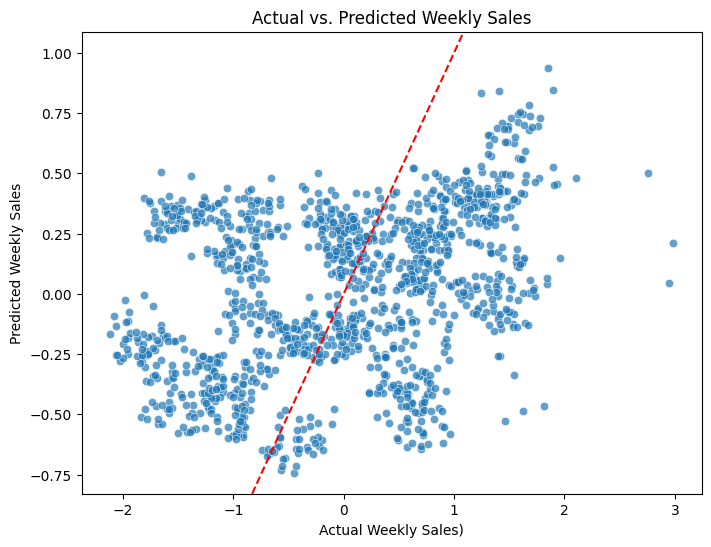

In [86]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha = 0.7)
plt.xlabel("Actual Weekly Sales)")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs. Predicted Weekly Sales")
plt.axline([0,0],[1,1],color = "red",linestyle="--")

In [87]:
from sklearn.ensemble import RandomForestRegressor

In [89]:
rf_model = RandomForestRegressor(n_estimators =100,random_state = 42)
rf_model.fit(X_train,y_train)


RandomForestRegressor(random_state=42)

In [90]:
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = mean_squared_error(y_test,y_pred)**0.5
print(f"Random Forest R^2 Score: {r2:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")

Random Forest R^2 Score: 0.9619
Random Forest RMSE: 0.1976
